### Import Packages 

In [65]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

### Load Data

In [66]:
file_path = '/Users/baselhussein/Projects/impossible_goals/data/cluster_features.csv'
ids_file_path = '/Users/baselhussein/Projects/impossible_goals/unique_ids.csv'

In [67]:
data = pd.read_csv(file_path)
ids = pd.read_csv(ids_file_path)

In [68]:
data

,ID,unique_goals,total_returns,seconds_per_goal,seconds_to_first_goal_switch,impasses,input_count_exploring,time_in_level_seconds,avg_impasse_per_goal
0,2,2,0,18.233000,13.416,7,110,82.466,7.000000
1,6,2,0,4.408000,8.816,0,15,13.050,0.000000
2,12,7,9,12.821286,17.533,17,230,148.016,1.666667
3,13,6,2,18.163833,9.300,52,365,281.800,8.200000
4,22,2,0,7.533500,15.067,9,31,24.300,9.000000
...,...,...,...,...,...,...,...,...,...
145,252,7,7,53.342714,14.133,48,371,513.935,7.666667
146,253,7,23,41.769000,10.450,91,751,562.183,10.833333
147,255,6,10,34.372000,8.283,65,298,305.316,11.600000
148,257,5,11,102.930000,25.350,41,124,586.083,9.500000


In [69]:
### Drop Outliers 

In [70]:
# Specify the column to use
column_name = 'seconds_to_first_goal_switch'

# Calculate mean and standard deviation
mean = data[column_name].mean()
std = data[column_name].std()

# Filter rows within 3 standard deviations
data = data.query(f'({mean} - 3 * {std} <= {column_name}) & ({column_name} <= {mean} + 3 * {std})')

In [71]:
ids

,IDs
0,6
1,12
2,13
3,22
4,23
...,...
90,242
91,245
92,248
93,251


In [72]:
data = data[data['ID'].isin(ids['IDs'])]
data

,ID,unique_goals,total_returns,seconds_per_goal,seconds_to_first_goal_switch,impasses,input_count_exploring,time_in_level_seconds,avg_impasse_per_goal
1,6,2,0,4.408000,8.816,0,15,13.050,0.000000
2,12,7,9,12.821286,17.533,17,230,148.016,1.666667
3,13,6,2,18.163833,9.300,52,365,281.800,8.200000
4,22,2,0,7.533500,15.067,9,31,24.300,9.000000
5,23,3,1,93.656000,31.500,14,111,390.267,5.000000
...,...,...,...,...,...,...,...,...,...
138,242,2,0,17.183000,34.366,11,80,61.866,11.000000
141,245,6,30,80.649333,8.450,57,585,748.466,8.400000
143,248,5,2,15.323200,7.817,16,123,114.167,3.750000
144,251,3,1,7.884000,2.500,5,33,53.150,2.000000


In [73]:
df_numeric = data.drop(columns=['ID'])

In [74]:
df_numeric.describe()

,unique_goals,total_returns,seconds_per_goal,seconds_to_first_goal_switch,impasses,input_count_exploring,time_in_level_seconds,avg_impasse_per_goal
count,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000
mean,4.106383,3.670213,24.024560,14.653681,21.542553,146.382979,177.284947,5.287728
std,1.731853,5.208323,22.358827,8.624575,26.555547,172.788460,196.454891,4.860477
min,2.000000,0.000000,2.425000,1.483000,0.000000,10.000000,8.900000,0.000000
25%,3.000000,0.000000,8.027625,8.012750,6.000000,28.250000,48.679500,2.250000
50%,4.000000,2.000000,15.231017,12.750000,11.500000,94.000000,108.250000,4.000000
75%,5.000000,5.000000,33.571750,18.670750,26.250000,171.750000,268.799750,6.750000
max,9.000000,30.000000,105.203167,39.350000,155.000000,910.000000,1084.185000,29.200000


In [75]:
correlation_matrix = df_numeric.corr()
correlation_matrix

,unique_goals,total_returns,seconds_per_goal,seconds_to_first_goal_switch,impasses,input_count_exploring,time_in_level_seconds,avg_impasse_per_goal
unique_goals,1.000000,0.712031,0.422017,0.027007,0.659928,0.786216,0.740695,0.235751
total_returns,0.712031,1.000000,0.627772,-0.046656,0.757518,0.816554,0.822351,0.428334
seconds_per_goal,0.422017,0.627772,1.000000,0.256202,0.727878,0.553952,0.827129,0.745911
seconds_to_first_goal_switch,0.027007,-0.046656,0.256202,1.000000,-0.001315,-0.040500,0.086559,0.163732
impasses,0.659928,0.757518,0.727878,-0.001315,1.000000,0.791249,0.874992,0.759555
input_count_exploring,0.786216,0.816554,0.553952,-0.040500,0.791249,1.000000,0.879368,0.387004
time_in_level_seconds,0.740695,0.822351,0.827129,0.086559,0.874992,0.879368,1.000000,0.570913
avg_impasse_per_goal,0.235751,0.428334,0.745911,0.163732,0.759555,0.387004,0.570913,1.000000


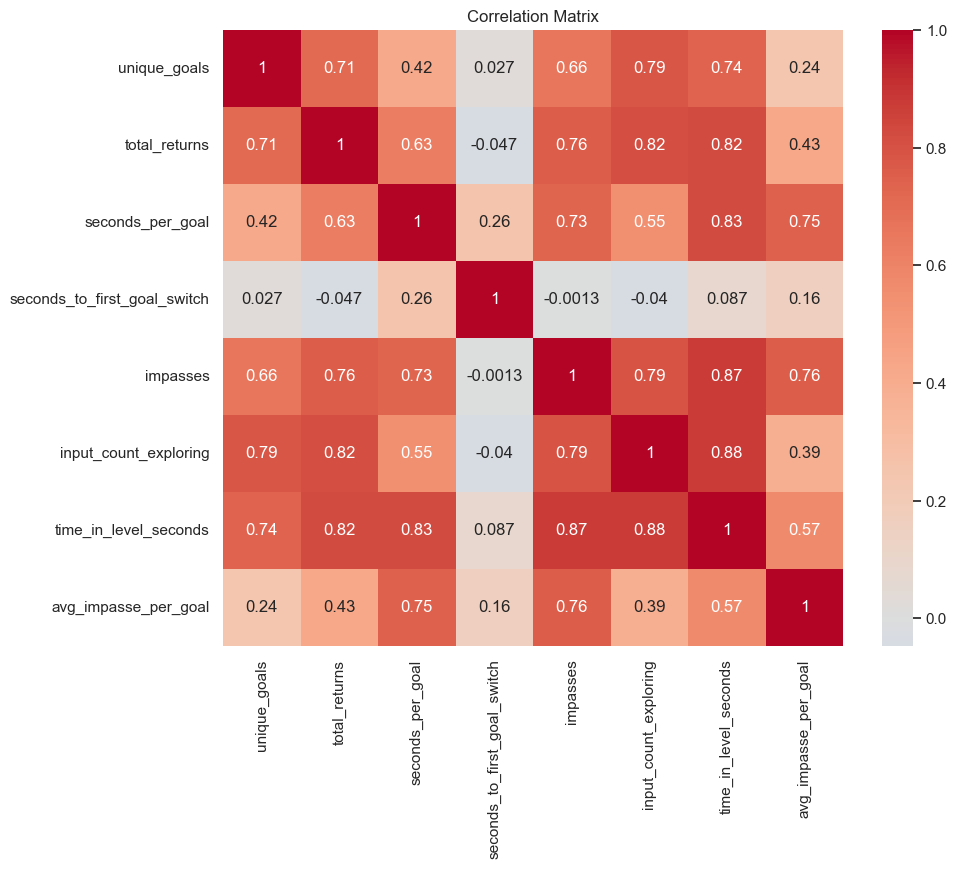

In [76]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

### Preprocessing

#### Clean ID Column 

In [77]:
data_clean = data.drop(columns=['ID', 'input_count_exploring', 'time_in_level_seconds', 
                                'seconds_per_goal', 'unique_goals', 'impasses', 'avg_impasse_per_goal',
                                'impasses'])
data_clean

,total_returns,seconds_to_first_goal_switch
1,0,8.816
2,9,17.533
3,2,9.300
4,0,15.067
5,1,31.500
...,...,...
138,0,34.366
141,30,8.450
143,2,7.817
144,1,2.500


#### Standardize Data

In [78]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_clean)

### Clustering

In [79]:
linked = linkage(data_scaled, method='ward')

### Dendrogram

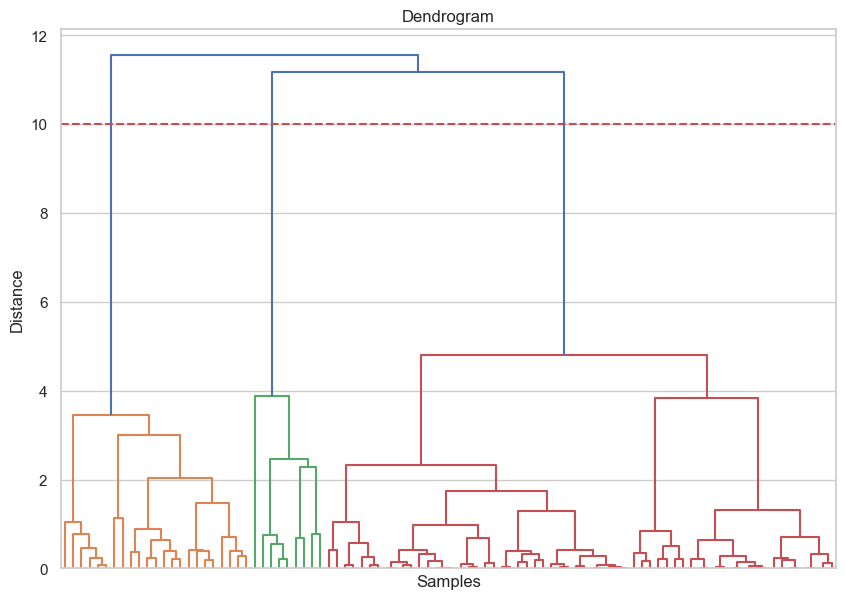

In [80]:
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', no_labels=True)
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.axhline(y=10, color='r', linestyle='--')  # Example threshold
plt.show()

In [81]:
# import pandas as pd
# import numpy as np
# from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
# from sklearn.metrics import silhouette_score
# import matplotlib.pyplot as plt

# # Perform hierarchical/agglomerative clustering
# linked = linkage(data_scaled, method='ward')

# # Plot dendrogram to visualize the hierarchical clustering
# plt.figure(figsize=(10, 7))
# dendrogram(linked)
# plt.show()

# # Function to compute silhouette score for different thresholds
# def compute_silhouette_score(data_scaled, linked, thresholds):
#     scores = {}
#     for threshold in thresholds:
#         clusters = fcluster(linked, t=threshold, criterion='distance')
#         # Check if we have more than one cluster
#         if len(set(clusters)) > 1:
#             score = silhouette_score(data_scaled, clusters)
#             scores[threshold] = score
#         else:
#             scores[threshold] = -1  # Assign a low score if only one cluster
#     return scores

# # Define a range of thresholds to test
# thresholds = np.arange(2, 20, 1)

# # Compute silhouette scores for different thresholds
# silhouette_scores = compute_silhouette_score(data_scaled, linked, thresholds)

# # Print the silhouette scores
# for threshold, score in silhouette_scores.items():
#     print(f"Threshold: {threshold}, Silhouette Score: {score}")

# # Find the best threshold based on silhouette score
# best_threshold = max(silhouette_scores, key=silhouette_scores.get)
# print(f"Best Threshold: {best_threshold}, Best Silhouette Score: {silhouette_scores[best_threshold]}")

# # Form flat clusters using the best threshold
# clusters = fcluster(linked, t=best_threshold, criterion='distance')

# # Add the cluster labels to the original data_scaledset
# data_scaled['Cluster'] = clusters

# # Display the first few rows of the updated data_scaledset
# print(data_scaled.head())

### Add Clusters to Data 

In [82]:
# Form flat clusters using the specified threshold
threshold = 5
clusters = fcluster(linked, t=threshold, criterion='distance')

# Add the cluster labels to the original dataset
data['Cluster'] = clusters

# Display the first few rows of the updated dataset
data.head()

,ID,unique_goals,total_returns,seconds_per_goal,seconds_to_first_goal_switch,impasses,input_count_exploring,time_in_level_seconds,avg_impasse_per_goal,Cluster
1,6,2,0,4.408000,8.816,0,15,13.050,0.000000,3
2,12,7,9,12.821286,17.533,17,230,148.016,1.666667,3
3,13,6,2,18.163833,9.300,52,365,281.800,8.200000,3
4,22,2,0,7.533500,15.067,9,31,24.300,9.000000,3
5,23,3,1,93.656000,31.500,14,111,390.267,5.000000,1


In [83]:
descriptive_stats = data.groupby('Cluster').agg(['mean', 'median', 'std', 'min', 'max'])
descriptive_stats

ID                            unique_goals                   \
               mean median        std min  max         mean median       std   
Cluster                                                                        
1        141.434783  147.0  79.797372  23  242     4.086957    4.0  1.411416   
2        143.777778  153.0  68.865408  45  245     6.777778    6.0  1.641476   
3        147.532258  161.0  74.826514   6  252     3.725806    3.0  1.516784   

                 ... time_in_level_seconds                                 \
        min max  ...                  mean    median         std      min   
Cluster          ...                                                        
1         2   7  ...            192.205043  144.7670  117.298159   27.816   
2         4   9  ...            601.203667  603.2160  283.156229  213.867   
3         2   8  ...            110.213484   79.1245  110.422475    8.900   

                  avg_impasse_per_goal                                   
              max                 mean median       std       min   max  
Cluster                                                                  
1         412.817             6.381159    5.0  5.050011  0.666667  24.0  
2        1084.185            12.429762   10.4  7.107663  6.333333  29.2  
3         513.935             3.845353    3.0  3.178518  0.000000  16.0  

[3 rows x 45 columns]

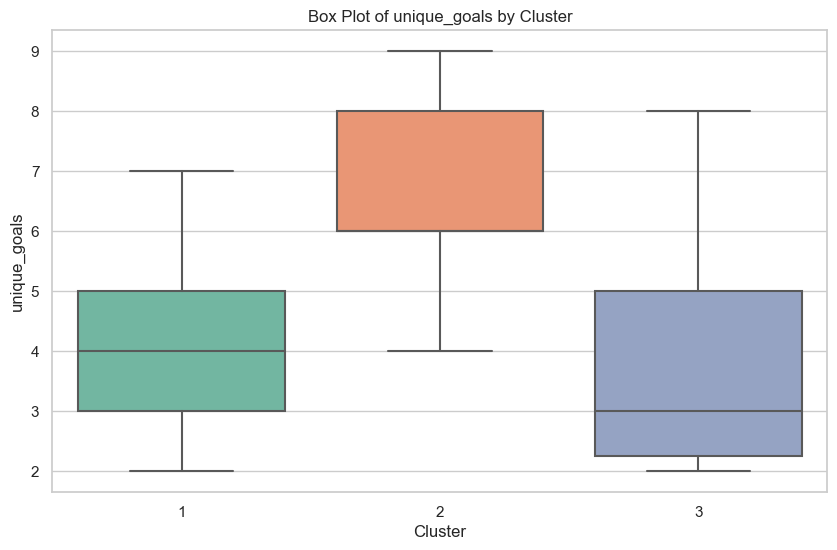

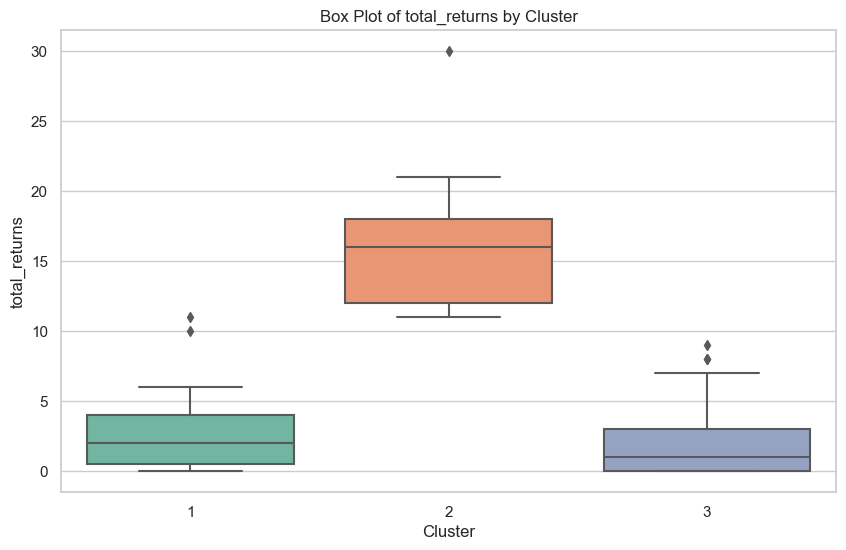

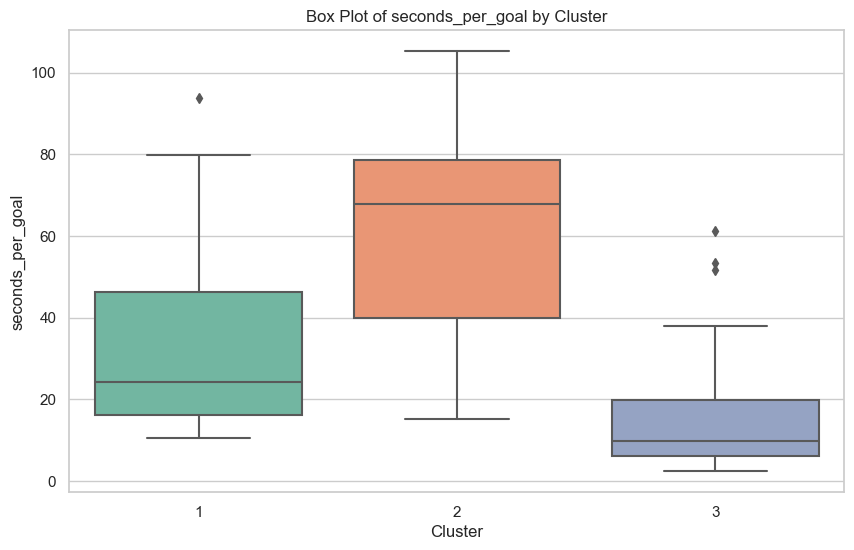

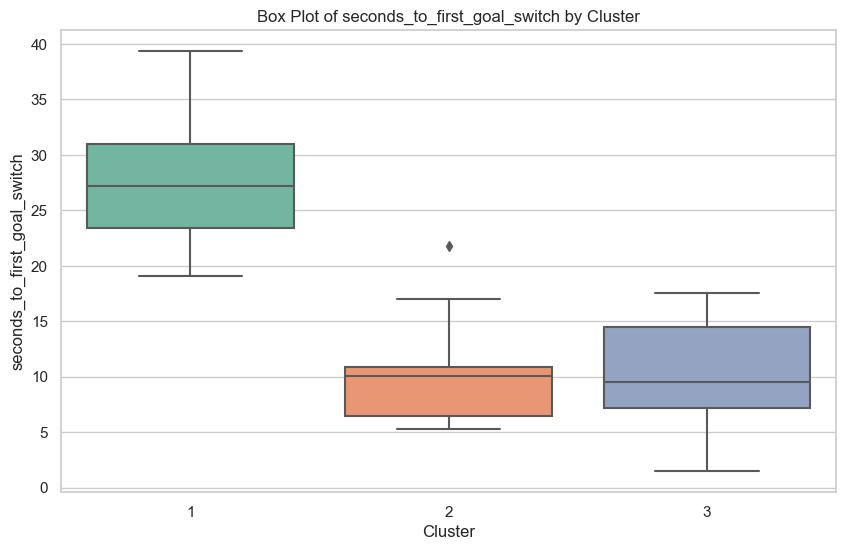

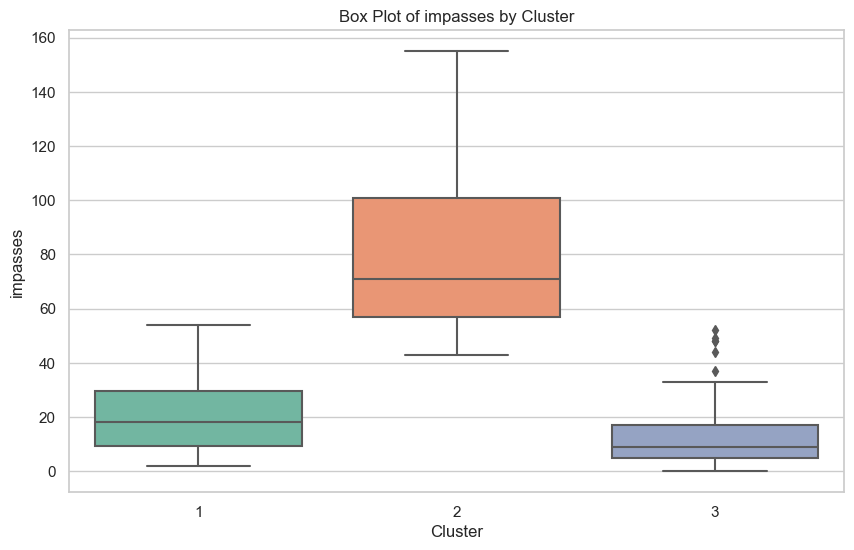

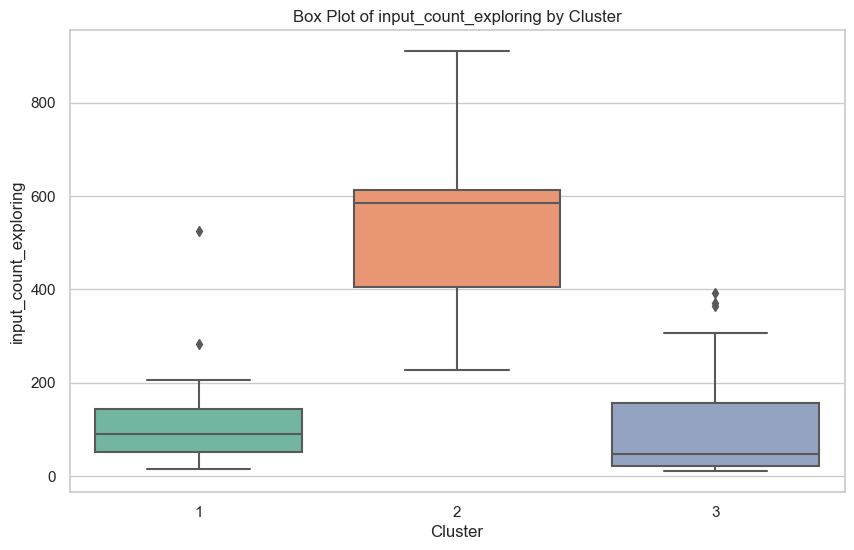

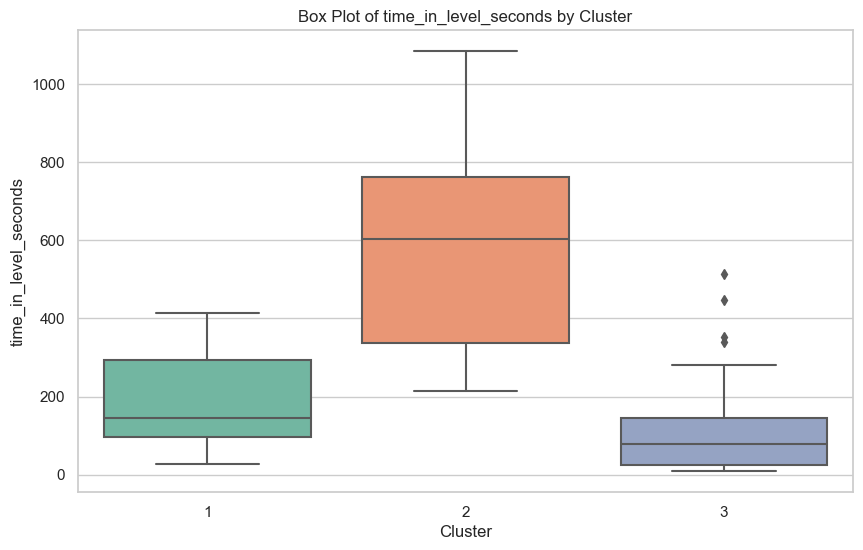

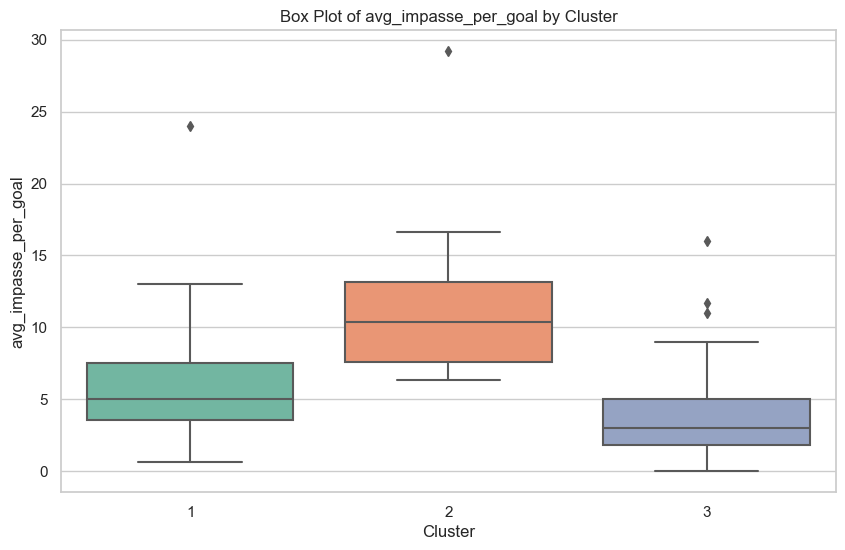

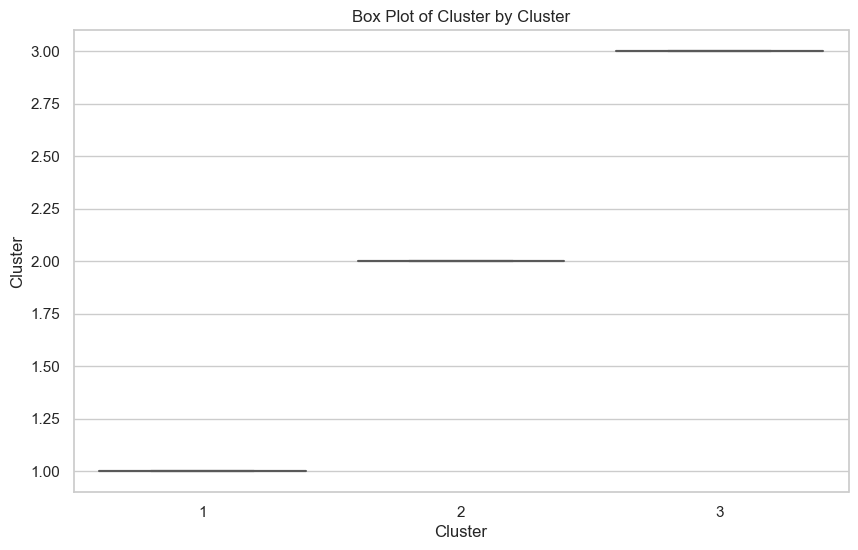

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


# Function to create box plots for each numeric column grouped by 'Cluster'
def plot_boxplots(data, numeric_columns):
    for column in numeric_columns:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=data, x='Cluster', y=column, palette='Set2')
        plt.title(f'Box Plot of {column} by Cluster')
        plt.xlabel('Cluster')
        plt.ylabel(column)
        plt.show()


# List of numeric columns
numeric_columns = data.columns[data.dtypes != 'object'].tolist()
numeric_columns.remove('ID')  # Exclude ID as it's not a relevant numeric column for analysis


# Plot box plots
plot_boxplots(data, numeric_columns)


### Export + Check 

In [85]:
data.to_csv('/Users/baselhussein/Projects/impossible_goals/bw_clusters.csv', index=False)

In [86]:
# descriptive_stats.to_csv('/Users/baselhussein/Projects/impossible_goals/output/cluster_descriptives.csv')
# data.to_csv()